# 04 - Latent Analysis with Rich Visualizations

This notebook performs post-training latent-space analysis for the trained Beta-VAE model.

## Analysis modules in this notebook
1. Reconstruction quality comparison (input vs reconstruction).
2. Latent traversal grid for selected dimensions.
3. Latent mean distribution histograms per dimension.
4. Latent-dimension correlation heatmap.
5. Average KL contribution per latent dimension.
6. Decoder sensitivity (dimension impact) bar chart.
7. Random prior sampling grid.
8. Interpolation between two real sneaker samples in latent space.

In [15]:

import os
import warnings

# Silence Python-level warnings in notebook output.
warnings.filterwarnings('ignore')

# Reduce noisy runtime warnings from OpenMP/MKL in some environments.
os.environ['KMP_WARNINGS'] = '0'
os.environ['MKL_VERBOSE'] = '0'

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [16]:

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'processed_sneakers_64x64').exists() or (cwd / 'BayesML_Final_Project.ipynb').exists():
        return cwd
    if (cwd / '..' / 'processed_sneakers_64x64').resolve().exists() or (cwd / '..' / 'BayesML_Final_Project.ipynb').resolve().exists():
        return (cwd / '..').resolve()
    return cwd


PROJECT_ROOT = resolve_project_root()
PROJECT_ROOT


PosixPath('/Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE')

## Paths and Runtime Configuration

In [17]:

PROCESSED_DATA_DIR = PROJECT_ROOT / 'processed_sneakers_64x64'
CHECKPOINT_DIR = PROJECT_ROOT / 'artifacts' / 'checkpoints'

IMPROVED_CHECKPOINT_PATH = CHECKPOINT_DIR / 'beta_vae_improved.pt'
BASELINE_CHECKPOINT_PATH = CHECKPOINT_DIR / 'beta_vae_baseline.pt'

BATCH_SIZE = 128
NUM_WORKERS = 4
LATENT_DIM = 16

if not PROCESSED_DATA_DIR.exists():
    raise FileNotFoundError(
        f'Processed dataset not found at {PROCESSED_DATA_DIR}. '
        'Run 01_data_preprocessing.ipynb first.'
    )


## DataLoader

In [18]:

transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=PROCESSED_DATA_DIR, transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f'Dataset size: {len(dataset)}')
print(f'Class count: {len(dataset.classes)}')


Dataset size: 12856
Class count: 336


## Model Definition and Checkpoint Loading

In [19]:

class BetaVAE(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        self.fc_mu = nn.Linear(4096, latent_dim)
        self.fc_log_var = nn.Linear(4096, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 4096)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor):
        encoded = self.encoder(x)
        flat = torch.flatten(encoded, start_dim=1)
        mu = self.fc_mu(flat)
        log_var = self.fc_log_var(flat)
        z = self.reparameterize(mu, log_var)

        decoded = self.fc_decode(z)
        decoded = decoded.view(-1, 256, 4, 4)
        reconstruction = self.decoder(decoded)
        return reconstruction, mu, log_var


In [20]:

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

if IMPROVED_CHECKPOINT_PATH.exists():
    checkpoint_path = IMPROVED_CHECKPOINT_PATH
elif BASELINE_CHECKPOINT_PATH.exists():
    checkpoint_path = BASELINE_CHECKPOINT_PATH
else:
    raise FileNotFoundError(
        'No trained checkpoint found. Run 02_baseline_training.ipynb and/or '
        '03_improved_training_with_annealing.ipynb first.'
    )

checkpoint = torch.load(checkpoint_path, map_location=device)
latent_dim = checkpoint.get('latent_dim', LATENT_DIM)
model = BetaVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Using device: {device}')
print(f'Loaded checkpoint: {checkpoint_path}')
print(f'Latent dim: {latent_dim}')


Using device: mps
Loaded checkpoint: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/artifacts/checkpoints/beta_vae_improved.pt
Latent dim: 16


## Visualization Helpers

In [21]:
def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    image = tensor.detach().cpu().numpy()
    image = np.transpose(image, (1, 2, 0))
    return np.clip(image, 0.0, 1.0)


def show_reconstruction_grid(model: nn.Module, dataloader: DataLoader, device: torch.device, n_images: int = 8):
    model.eval()
    batch, _ = next(iter(dataloader))
    batch = batch[:n_images].to(device)

    with torch.no_grad():
        reconstruction, _, _ = model(batch)

    fig, axes = plt.subplots(2, n_images, figsize=(2.0 * n_images, 4.5))
    for i in range(n_images):
        axes[0, i].imshow(tensor_to_numpy_image(batch[i]))
        axes[0, i].axis('off')
        axes[0, i].set_title('Input' if i == 0 else '')

        axes[1, i].imshow(tensor_to_numpy_image(reconstruction[i]))
        axes[1, i].axis('off')
        axes[1, i].set_title('Recon' if i == 0 else '')

    plt.suptitle('Input vs Reconstruction')
    plt.tight_layout()
    plt.show()


def show_latent_traversal(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    latent_dim: int,
    dims_to_plot=None,
    steps: int = 9,
):
    model.eval()
    if dims_to_plot is None:
        dims_to_plot = list(range(min(latent_dim, 10)))

    real_batch, _ = next(iter(dataloader))
    base_img = real_batch[0:1].to(device)

    with torch.no_grad():
        _, base_mu, _ = model(base_img)

    traversal_values = torch.linspace(-3.0, 3.0, steps=steps, device=device)
    fig, axes = plt.subplots(len(dims_to_plot), steps, figsize=(steps * 1.6, len(dims_to_plot) * 1.5))
    if len(dims_to_plot) == 1:
        axes = np.expand_dims(axes, 0)

    with torch.no_grad():
        for row, dim in enumerate(dims_to_plot):
            for col, value in enumerate(traversal_values):
                z = base_mu.clone()
                z[0, dim] = value
                decoded = model.fc_decode(z).view(-1, 256, 4, 4)
                generated = model.decoder(decoded)

                axes[row, col].imshow(tensor_to_numpy_image(generated[0]))
                axes[row, col].axis('off')
                if col == 0:
                    axes[row, col].set_title(f'Dim {dim}', loc='left', fontsize=10)

    plt.suptitle('Latent Traversal Grid')
    plt.tight_layout()
    plt.show()


def collect_latent_statistics(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    max_batches: int = 60,
):
    model.eval()
    all_mu = []
    all_logvar = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            _, mu, logvar = model(images)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_labels.append(labels)

            if batch_idx + 1 >= max_batches:
                break

    mu_tensor = torch.cat(all_mu, dim=0)
    logvar_tensor = torch.cat(all_logvar, dim=0)
    label_tensor = torch.cat(all_labels, dim=0)
    return mu_tensor.numpy(), logvar_tensor.numpy(), label_tensor.numpy()


def show_latent_histograms(mu_array: np.ndarray, max_dims: int = 12, bins: int = 40):
    dims = min(mu_array.shape[1], max_dims)
    cols = 4
    rows = int(np.ceil(dims / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.8 * rows))
    axes = np.array(axes).reshape(-1)

    for dim in range(dims):
        axes[dim].hist(mu_array[:, dim], bins=bins, alpha=0.8)
        axes[dim].set_title(f'Dim {dim}')
        axes[dim].set_xlabel('Mu value')
        axes[dim].set_ylabel('Count')

    for dim in range(dims, len(axes)):
        axes[dim].axis('off')

    plt.suptitle('Latent Mean Distribution by Dimension')
    plt.tight_layout()
    plt.show()


def show_latent_correlation_heatmap(mu_array: np.ndarray, max_dims: int = 16):
    dims = min(mu_array.shape[1], max_dims)
    corr = np.corrcoef(mu_array[:, :dims], rowvar=False)

    plt.figure(figsize=(7.2, 6.2))
    im = plt.imshow(corr, cmap='coolwarm', vmin=-1.0, vmax=1.0)
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Correlation')
    plt.title('Correlation Heatmap of Latent Means')
    plt.xlabel('Dimension')
    plt.ylabel('Dimension')
    plt.xticks(range(dims))
    plt.yticks(range(dims))
    plt.tight_layout()
    plt.show()


def show_average_kl_per_dimension(mu_array: np.ndarray, logvar_array: np.ndarray):
    kl_per_sample_dim = -0.5 * (1.0 + logvar_array - np.square(mu_array) - np.exp(logvar_array))
    mean_kl = kl_per_sample_dim.mean(axis=0)

    plt.figure(figsize=(8.5, 3.8))
    plt.bar(np.arange(len(mean_kl)), mean_kl)
    plt.title('Average KL Contribution per Latent Dimension')
    plt.xlabel('Dimension')
    plt.ylabel('Mean KL')
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()


def show_dimension_impact_bar(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    latent_dim: int,
    delta: float = 2.0,
    max_dims: int = 16,
):
    model.eval()
    dims = min(latent_dim, max_dims)

    real_batch, _ = next(iter(dataloader))
    base_img = real_batch[0:1].to(device)

    with torch.no_grad():
        _, base_mu, _ = model(base_img)
        base_decode = model.fc_decode(base_mu).view(-1, 256, 4, 4)
        base_gen = model.decoder(base_decode)

        impact_scores = []
        for dim in range(dims):
            z_plus = base_mu.clone()
            z_minus = base_mu.clone()
            z_plus[0, dim] += delta
            z_minus[0, dim] -= delta

            plus_img = model.decoder(model.fc_decode(z_plus).view(-1, 256, 4, 4))
            minus_img = model.decoder(model.fc_decode(z_minus).view(-1, 256, 4, 4))

            diff_plus = torch.mean(torch.abs(plus_img - base_gen)).item()
            diff_minus = torch.mean(torch.abs(minus_img - base_gen)).item()
            impact_scores.append(0.5 * (diff_plus + diff_minus))

    plt.figure(figsize=(8.5, 3.8))
    plt.bar(np.arange(dims), impact_scores)
    plt.title(f'Latent Dimension Impact (Delta = {delta})')
    plt.xlabel('Dimension')
    plt.ylabel('Mean Absolute Pixel Change')
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()


def show_random_prior_samples(model: nn.Module, device: torch.device, latent_dim: int, n_samples: int = 16):
    model.eval()
    cols = 4
    rows = int(np.ceil(n_samples / cols))

    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim, device=device)
        decoded = model.fc_decode(z).view(-1, 256, 4, 4)
        generated = model.decoder(decoded)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.3, rows * 2.3))
    axes = np.array(axes).reshape(-1)
    for i in range(n_samples):
        axes[i].imshow(tensor_to_numpy_image(generated[i]))
        axes[i].axis('off')
        axes[i].set_title(f'Sample {i + 1}', fontsize=8)

    for i in range(n_samples, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Random Prior Samples (z ~ N(0, I))')
    plt.tight_layout()
    plt.show()


def show_latent_interpolation(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    steps: int = 10,
):
    model.eval()
    images, _ = next(iter(dataloader))
    if images.shape[0] < 2:
        raise ValueError('Need at least two images in one batch for interpolation.')

    img_a = images[0:1].to(device)
    img_b = images[1:2].to(device)

    with torch.no_grad():
        _, mu_a, _ = model(img_a)
        _, mu_b, _ = model(img_b)

    alphas = torch.linspace(0.0, 1.0, steps=steps, device=device)

    fig, axes = plt.subplots(1, steps, figsize=(2.2 * steps, 2.7))
    with torch.no_grad():
        for i, alpha in enumerate(alphas):
            z = (1 - alpha) * mu_a + alpha * mu_b
            decoded = model.fc_decode(z).view(-1, 256, 4, 4)
            generated = model.decoder(decoded)
            axes[i].imshow(tensor_to_numpy_image(generated[0]))
            axes[i].axis('off')
            axes[i].set_title(f'{float(alpha):.2f}')

    plt.suptitle('Latent Interpolation Between Two Real Samples')
    plt.tight_layout()
    plt.show()

## Run Visual Analyses

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


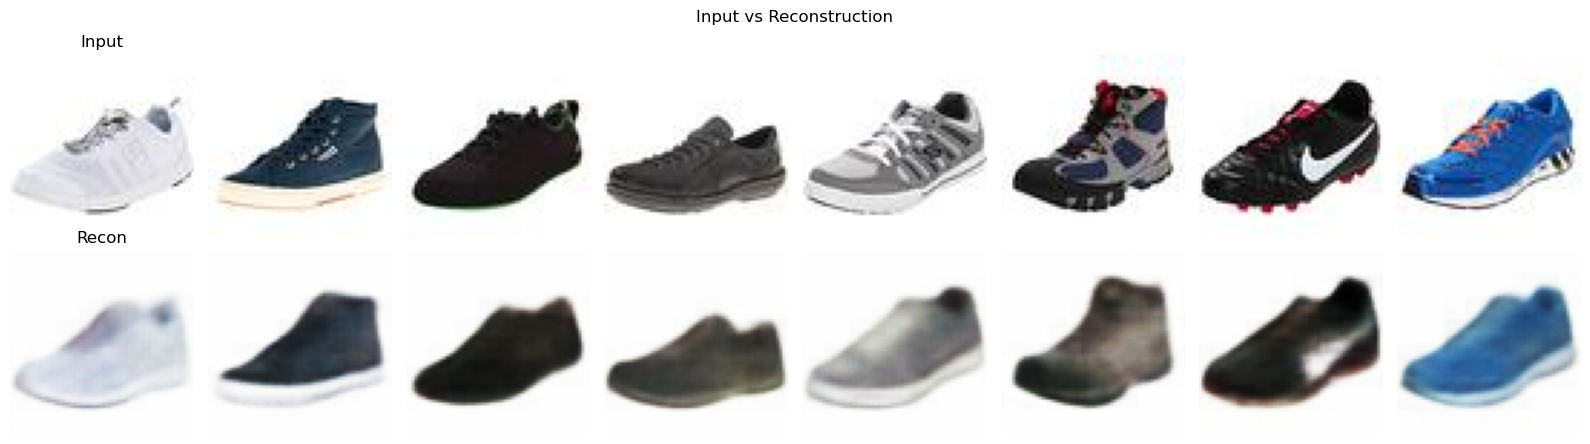

In [22]:

show_reconstruction_grid(model, dataloader, device, n_images=8)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


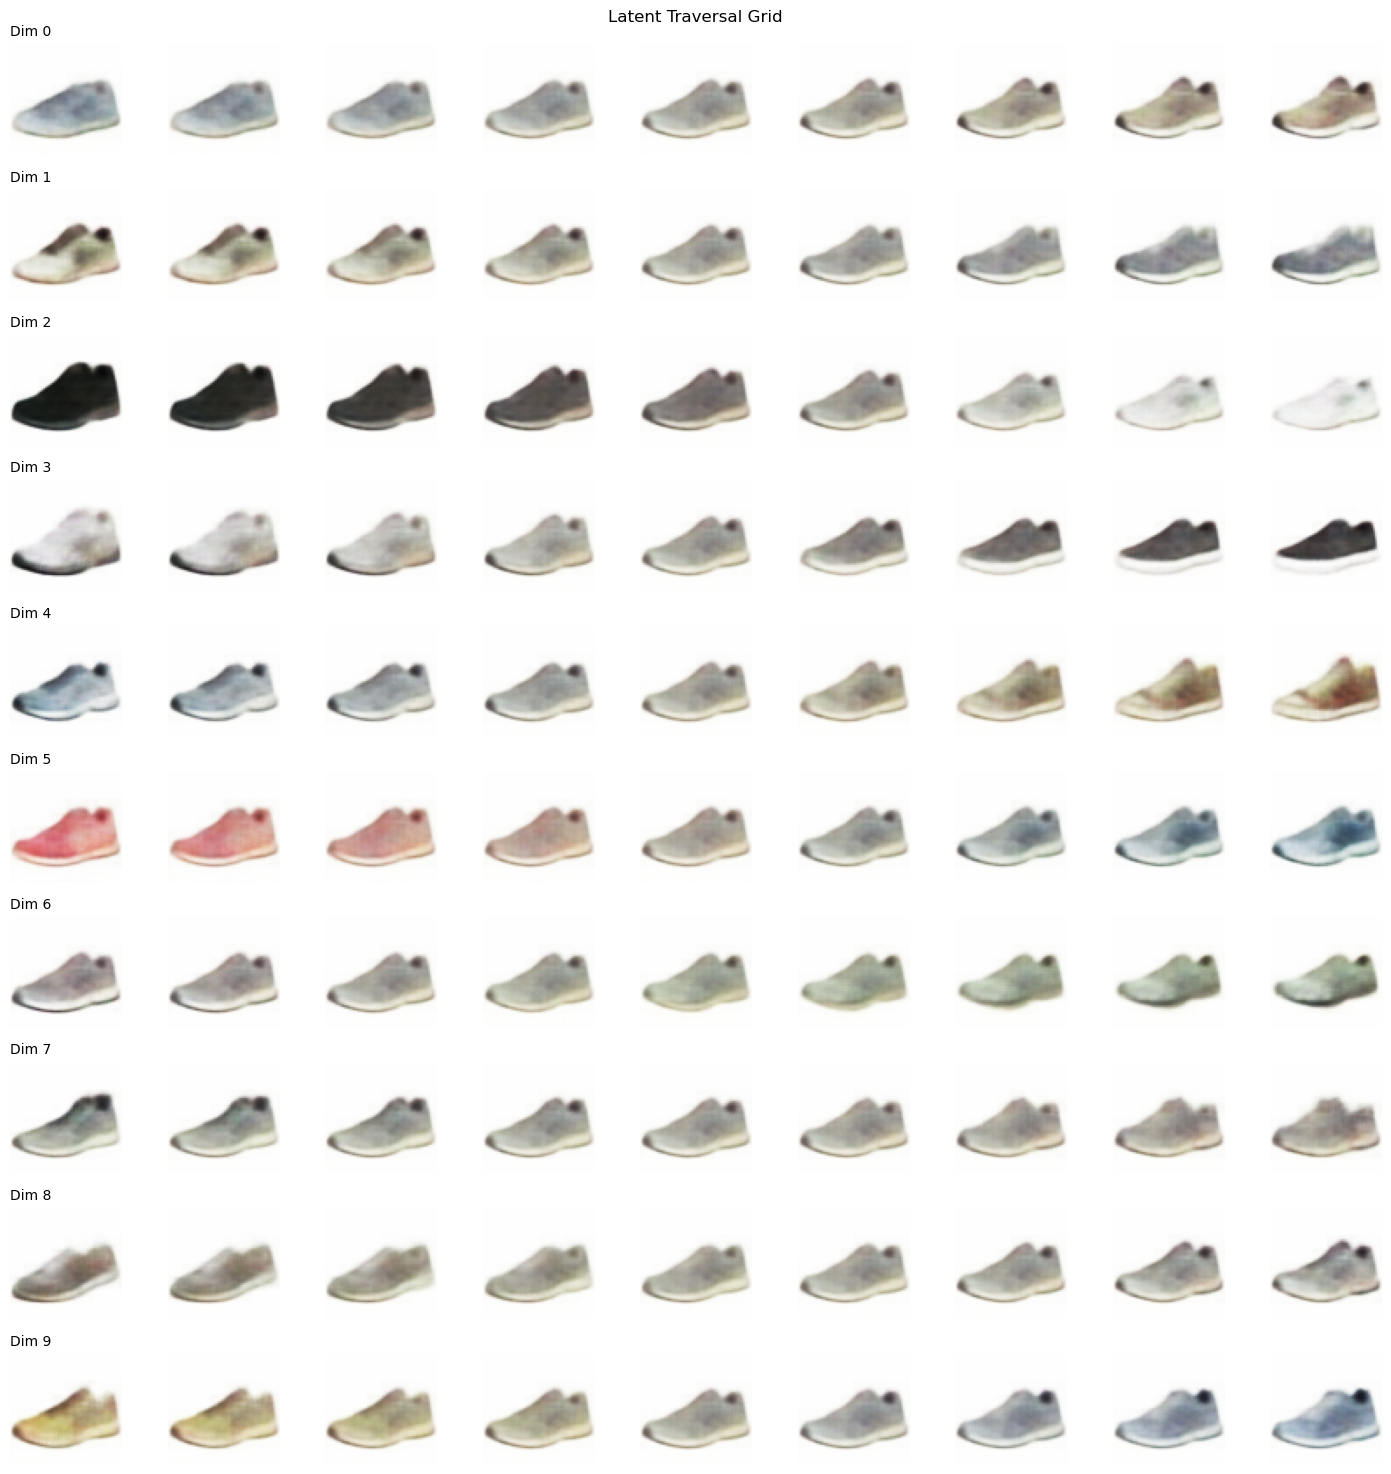

In [23]:

show_latent_traversal(
    model=model,
    dataloader=dataloader,
    device=device,
    latent_dim=latent_dim,
    dims_to_plot=list(range(min(10, latent_dim))),
    steps=9,
)


In [24]:
mu_array, logvar_array, label_array = collect_latent_statistics(
    model=model,
    dataloader=dataloader,
    device=device,
    max_batches=60,
)
print('Collected latent statistics:', mu_array.shape, logvar_array.shape)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


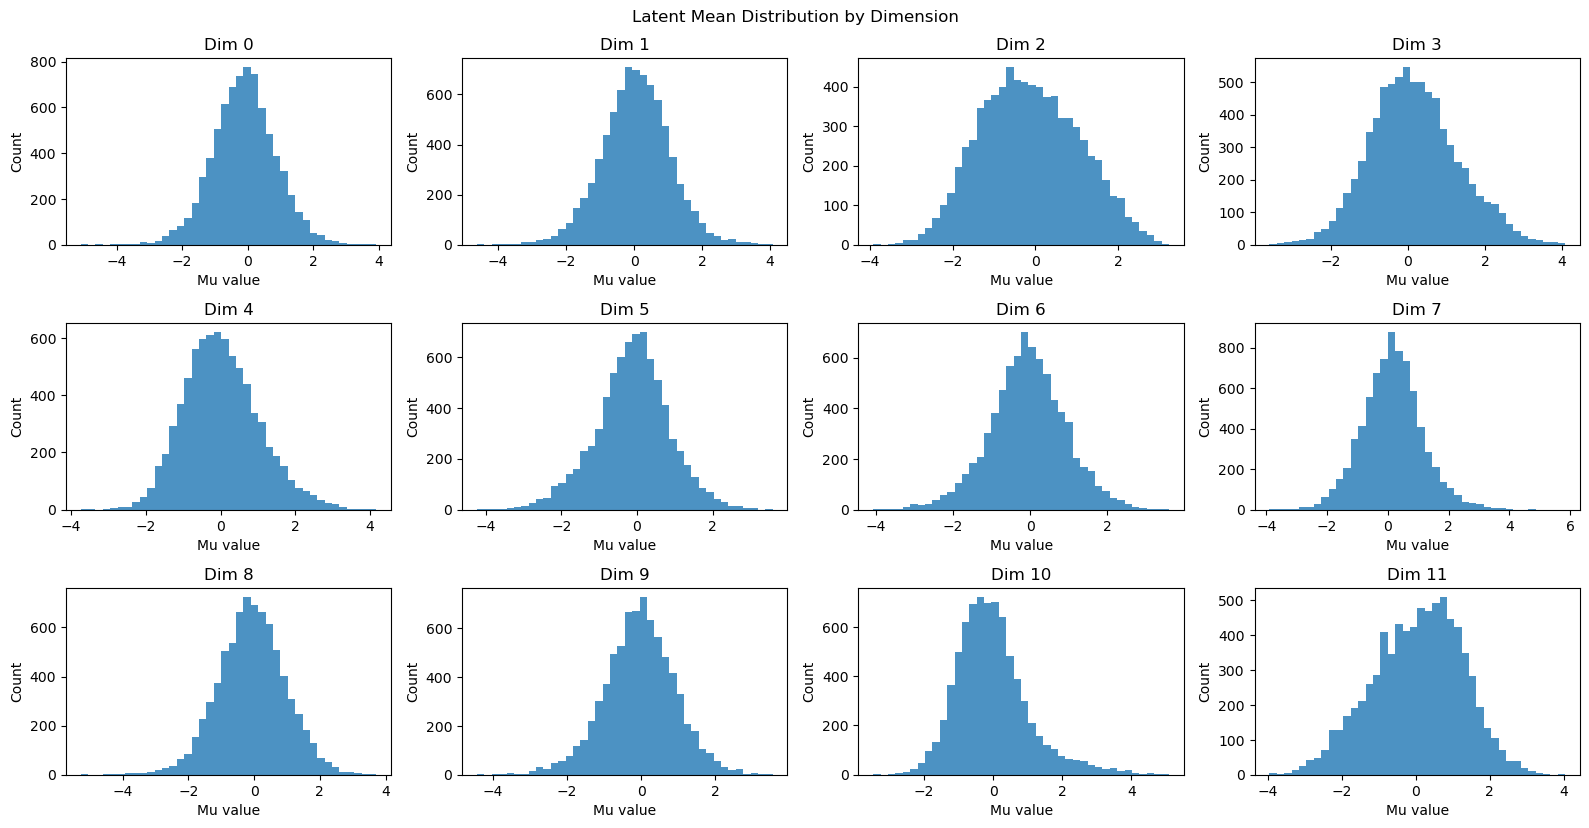

In [25]:
show_latent_histograms(mu_array, max_dims=12, bins=40)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


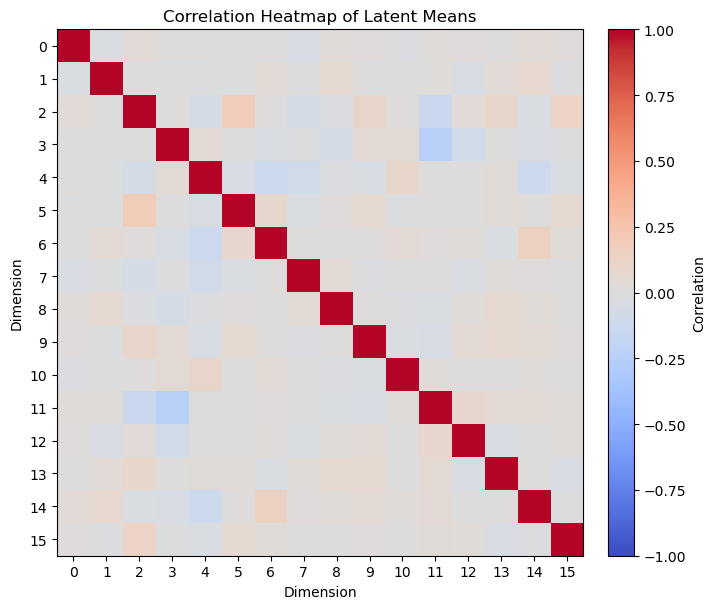

In [26]:
show_latent_correlation_heatmap(mu_array, max_dims=min(16, latent_dim))

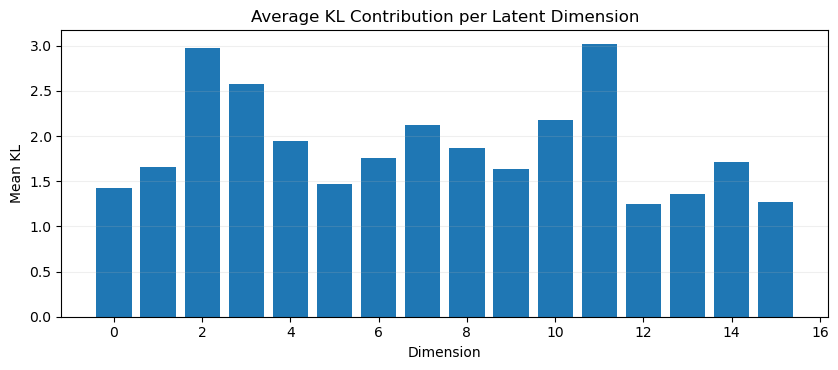

In [27]:
show_average_kl_per_dimension(mu_array, logvar_array)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


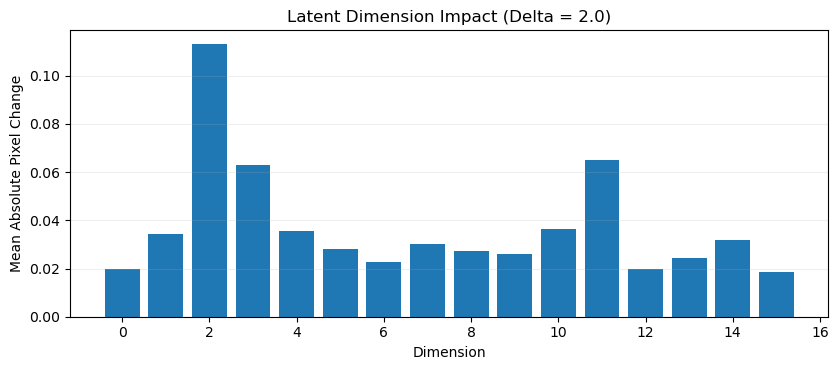

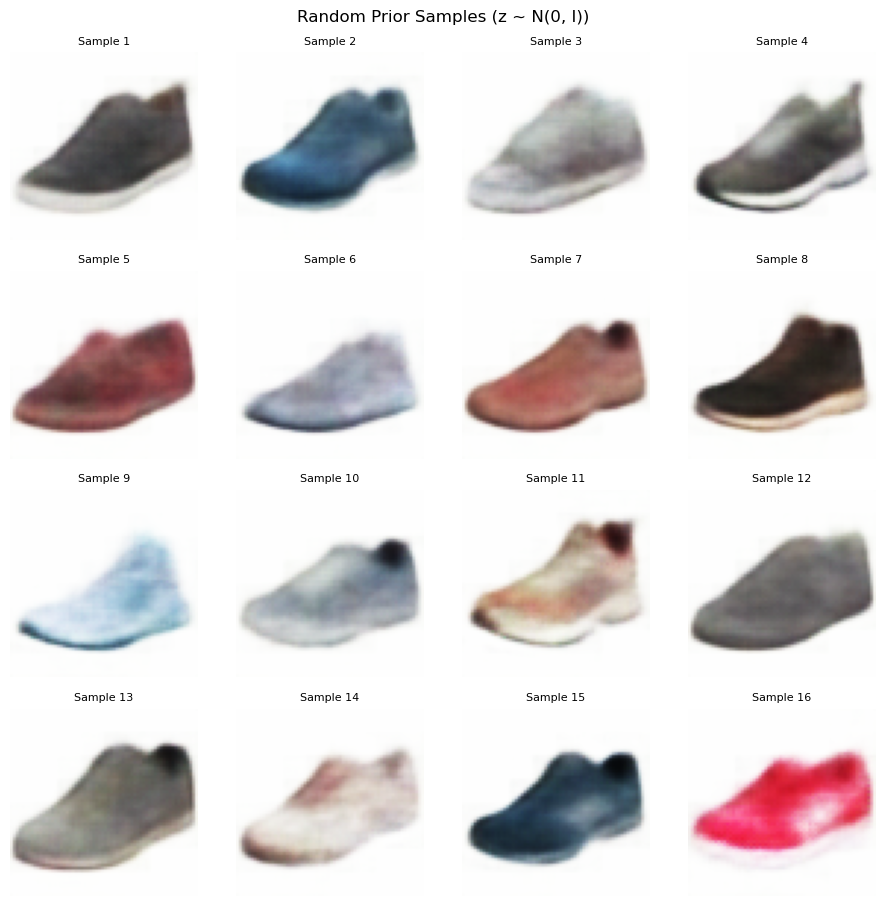

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


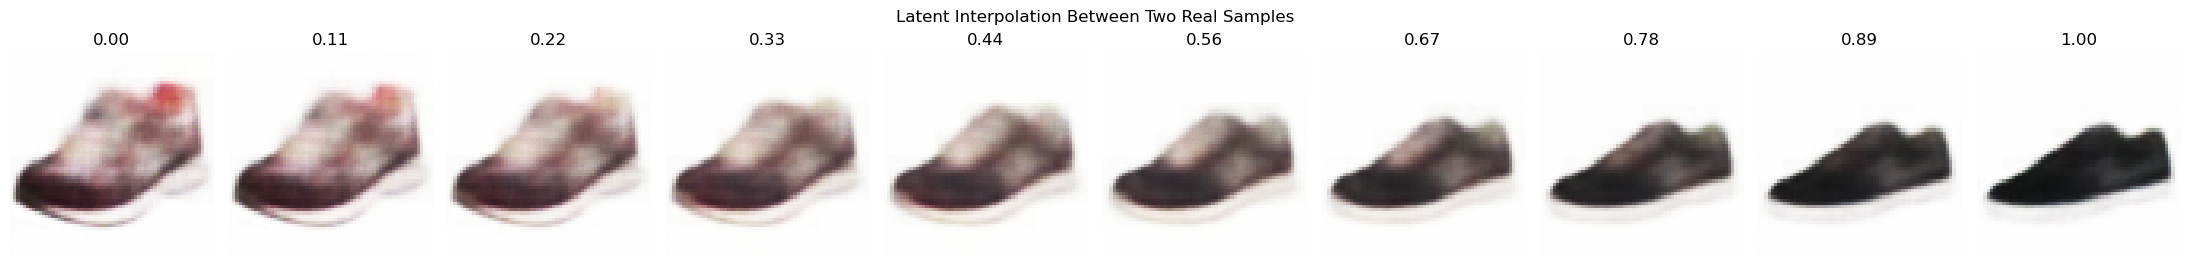

In [28]:
show_dimension_impact_bar(
    model=model,
    dataloader=dataloader,
    device=device,
    latent_dim=latent_dim,
    delta=2.0,
    max_dims=min(16, latent_dim),
)

show_random_prior_samples(model, device, latent_dim=latent_dim, n_samples=16)
show_latent_interpolation(model, dataloader, device, steps=10)